In [ ]:
# Connect Google Colab to Google Drive to access stored datasets and save outputs
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Define paths for data loading and extraction
DATA_ROOT = '/content/drive/MyDrive/flame_data'
IMG_ZIP = f"{DATA_ROOT}/Images.zip"
MASK_ZIP = f"{DATA_ROOT}/Masks.zip"

# Specify a directory within Colab's local filesystem for unzipping
EXTRACT_PATH = '/content/flame_data'

In [ ]:
# Create the extraction directory if it doesn't already exist
import os

os.makedirs(EXTRACT_PATH, exist_ok=True)

# Unzip the image and mask datasets into their respective subdirectories
!unzip -q "{IMG_ZIP}" -d "{EXTRACT_PATH}/images"
!unzip -q "{MASK_ZIP}" -d "{EXTRACT_PATH}/masks"

In [ ]:
# Define the full paths to the extracted images and masks
images_path = f"{EXTRACT_PATH}/images/Images"
masks_path = f"{EXTRACT_PATH}/masks/Masks"

# List and sort all image and mask filenames to ensure a consistent order
image_files = sorted(os.listdir(images_path))
mask_files = sorted(os.listdir(masks_path))

print("Image Example:", image_files[:3])
print("Masck Example:", mask_files[:3])
print("Image number:", len(image_files), "| Masks number:", len(mask_files))

Image Example: ['image_0.jpg', 'image_1.jpg', 'image_10.jpg']
Masck Example: ['image_0.png', 'image_1.png', 'image_10.png']
Image number: 2003 | Masks number: 2003


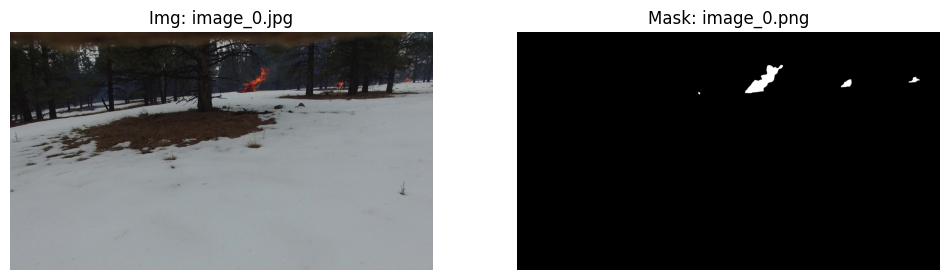

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

idx = 0

# Open the image and its corresponding mask using PIL
img = Image.open(os.path.join(images_path, image_files[idx]))
msk = np.array(Image.open(os.path.join(masks_path, mask_files[idx])))

# show image and its mask
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display the original image
axes[0].imshow(img)
axes[0].set_title(f"Img: {image_files[idx]}") # Set title with image filename
axes[0].axis("off") # Hide axes ticks and labels

# Display the mask. Using 'gray' colormap for binary masks
axes[1].imshow(msk, cmap="gray")
axes[1].set_title(f"Mask: {mask_files[idx]}")
axes[1].axis("off")

plt.show()

In [ ]:
import torchvision.transforms.functional as TF

def joint_transform(image, mask, size=(512, 512)):
    # Resize both the image and the mask to the specified 'size'
    image = TF.resize(image, size)
    mask = TF.resize(mask, size, interpolation=Image.NEAREST)

    # Convert the PIL image to a PyTorch tensor. This normalizes pixel to [0, 1]
    image = TF.to_tensor(image)
    mask = torch.as_tensor(np.array(mask), dtype=torch.long)

    return image, mask

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

# Define a custom PyTorch Dataset for loading flame segmentation images and masks
class FlameSegmentationDataset(Dataset):
  def __init__(self, images_dir, masks_dir, image_files, mask_files, size=(512, 512)):
    self.images_dir = images_dir
    self.masks_dir = masks_dir
    self.image_files = image_files
    self.mask_files = mask_files
    self.size = size

  # Returns the total number of samples in the dataset
  def __len__(self):
    return len(self.image_files)

  # Retrieves an image-mask pair by index
  def __getitem__(self, idx):
    img_path = os.path.join(self.images_dir, self.image_files[idx])
    mask_path = os.path.join(self.masks_dir, self.mask_files[idx])

    # Open the image and convert it to RGB format
    image = Image.open(img_path).convert("RGB")
    # Open the mask and convert it to grayscale
    mask = Image.open(mask_path).convert("L")

    # Apply the joint_transform to resize and convert image/mask to tensors
    image, mask = joint_transform(image, mask, size=self.size)

    return image, mask

In [ ]:
# Create an instance of the FlameSegmentationDataset for testing
test_dataset = FlameSegmentationDataset(
    images_dir=images_path,
    masks_dir=masks_path,
    image_files=image_files,
    mask_files=mask_files,
    size=(512, 512)
)

# Retrieve the first image and mask from the dataset to inspect their properties
img_tensor, mask_tensor = test_dataset[0]

# Print the shape, data type, and min/max
print("Img Shape:", img_tensor.shape)
print("Img Type:", img_tensor.dtype)
print("Min/Max Img value:", img_tensor.min().item(), img_tensor.max().item())

# Print the shape, data type, and unique values of the mask tensor.
print("\nMask Shape:", mask_tensor.shape)
print("Mask Type:", mask_tensor.dtype)
print("unique mask value:", torch.unique(mask_tensor))

Shape immagine: torch.Size([3, 512, 512])
Tipo immagine: torch.float32
Min/Max valori immagine: 0.03529411926865578 0.8549019694328308

Shape maschera: torch.Size([512, 512])
Tipo maschera: torch.int64
Valori unici maschera: tensor([0, 1])


In [ ]:
# Re-list and sort the image and mask filenames to ensure image matches with their masks.
image_files = sorted(os.listdir(images_path))
mask_files = sorted(os.listdir(masks_path))

print("Image number:", len(image_files))
print("Mask number:", len(mask_files))
print("Ex:", image_files[:3], mask_files[:3])

Numero immagini: 2003
Numero maschere: 2003
Esempi: ['image_0.jpg', 'image_1.jpg', 'image_10.jpg'] ['image_0.png', 'image_1.png', 'image_10.png']


In [ ]:
from sklearn.model_selection import train_test_split

SEED = 42

# First split: Separate 15% of the data for the test set.
train_val_imgs, test_imgs, train_val_masks, test_masks = train_test_split(
    image_files,
    mask_files,
    test_size=0.15,
    random_state=SEED
)

# Second split: From the 'train_val' set (85% of original), further split into training and validation.
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    train_val_imgs,
    train_val_masks,
    test_size=0.176, # 15%/85%
    random_state=SEED
)

# Create separate Dataset for training, validation, and testing.
train_dataset = FlameSegmentationDataset(
    images_dir=images_path,
    masks_dir=masks_path,
    image_files=train_imgs,
    mask_files=train_masks,
    size=(512, 512)
)

val_dataset = FlameSegmentationDataset(
    images_dir=images_path,
    masks_dir=masks_path,
    image_files=val_imgs,
    mask_files=val_masks,
    size=(512, 512)
)

test_dataset = FlameSegmentationDataset(
    images_dir=images_path,
    masks_dir=masks_path,
    image_files=test_imgs,
    mask_files=test_masks,
    size=(512, 512)
)

print("Train:", len(train_imgs))
print("Validation:", len(val_imgs))
print("Test:", len(test_imgs))

Train: 1402
Validation: 300
Test: 301


In [ ]:
from torch.utils.data import DataLoader

# Processing 8 images and their corresponding mask at a time
BATCH_SIZE = 8

# Create a DataLoader for the training dataset.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2 # to load data in parallel
)

# Create a DataLoader for the validation dataset.
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # order does not matter
    num_workers=2
)

# Create a DataLoader for the test dataset.
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

# Get one batch of images and masks from the training loader to inspect their shapes.
images_batch, masks_batch = next(iter(train_loader))

print("Image Batch Shape:", images_batch.shape)
print("Mask Batch Shape:", masks_batch.shape)

Image Batch Shape: torch.Size([8, 3, 512, 512])
Mask Batch Shape: torch.Size([8, 512, 512])


In [ ]:
# pre trained Hugging Face Transformers
!pip install -q --upgrade transformers

In [ ]:
from transformers import SegformerForSemanticSegmentation

NUM_CLASSES = 2 # background (0) fire/smoke (1).

# Load a pre-trained SegFormer model for semantic segmentation.
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512", # pre-trained model
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)

print(model.config.num_labels)
print(model.decode_head.classifier)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `150`.


model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([2])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([2, 256, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


2
Conv2d(256, 2, kernel_size=(1, 1), stride=(1, 1))


In [ ]:
# Set the model to evaluation mode.
model.eval()

# Disable gradient calculation for efficiency, as we are only inspecting the output and not performing backpropagation.
with torch.no_grad():
    outputs = model(pixel_values=images_batch)

print("Shape logits output:", outputs.logits.shape)

Shape logits output: torch.Size([8, 2, 128, 128])


In [ ]:
import torch.nn.functional as F

# Upsample the model's logits to match the original mask size.
upsampled_logits = F.interpolate(
    outputs.logits,
    size=masks_batch.shape[-2:],
    mode="bilinear",
    align_corners=False # ensure is working with different pythorch version
)

print("Shape logits after upsampling:", upsampled_logits.shape)

Shape logits after upsampling: torch.Size([8, 2, 512, 512])


In [ ]:
# Define the Cross-Entropy Loss function.
criterion = torch.nn.CrossEntropyLoss()

# Calculate the Cross-Entropy loss between the upsampled logits and the ground truth masks.
loss = criterion(upsampled_logits, masks_batch)

print("Loss:", loss.item())

Loss: 0.8398193717002869


In [ ]:
# Initialize the AdamW optimizer with a learning rate of 6e-5
optimizer = torch.optim.AdamW(model.parameters(), lr=6e-5)

In [ ]:
import numpy as np

# Initialize counters for pixels: background (0) fire/smoke (1).
total_0, total_1 = 0, 0

# Iterate through each mask in the training dataset to count pixel occurrences.
for _, mask in train_dataset:
    unique, counts = torch.unique(mask, return_counts=True)
    for val, count in zip(unique.tolist(), counts.tolist()):
        if val == 0:
            total_0 += count
        elif val == 1:
            total_1 += count

print(f"background's (0): {total_0} ({total_0/(total_0+total_1)*100:.2f}%)")
print(f"fire/smoke's pixel (1): {total_1} ({total_1/(total_0+total_1)*100:.2f}%)")

background's (0): 365380502 (99.42%)
fire/smoke's pixel (1): 2145386 (0.58%)


In [ ]:
# Calculate the total number of pixels.
total_pixels = total_0 + total_1

# Calculate class weights inversely proportional to their frequency.
# This technique gives more importance to under-represented classes during training,
weight_0 = total_pixels / (2 * total_0)
weight_1 = total_pixels / (2 * total_1)

# Create a PyTorch tensor for these class weights, ensuring it's of float32 type.
class_weights = torch.tensor([weight_0, weight_1], dtype=torch.float32)
print("Class weights:", class_weights)

Pesi delle classi: tensor([ 0.5029, 85.6550])


In [ ]:
class DiceLoss(torch.nn.Module):
  # Dice Loss function, useful for imbalanced segmentation tasks
  def __init__(self, smooth=1e-6):
    super().__init__()
    self.smooth = smooth

  def forward(self, logits, targets):

    # Apply softmax to convert logits to probabilities along the class dimension
    probs = torch.softmax(logits, dim=1)

    # Extract probabilities for the positive class
    probs_fire = probs[:, 1, :, :]

    # Create a binary target mask for the positive class
    targets_fire = (targets == 1).float()

    # Calculate the intersection between predicted probabilities and ground truth (approximates the true positives)
    intersection = (probs_fire * targets_fire).sum()

    # Calculate the union of predicted probabilities and ground truth (This approximates the sum of predicted positives and actual positives)
    union = probs_fire.sum() + targets_fire.sum()

    # Compute the Dice coefficient. 'smooth' is added to prevent division by zero
    dice_coeff = (2*intersection + self.smooth) / (union + self.smooth)

    return 1 - dice_coeff

In [ ]:
dice_loss_fn = DiceLoss()

# Define a combined loss function: Cross-Entropy Loss + Dice Loss.
def combined_loss(logits, targets, ce_weight=class_weights):
    ce = torch.nn.functional.cross_entropy(logits, targets, weight=ce_weight)
    dice = dice_loss_fn(logits, targets)
    return ce + dice

# Calculate a test combined loss using the upsampled logits and masks batch,
test_loss = combined_loss(upsampled_logits, masks_batch, ce_weight=class_weights.to(upsampled_logits.device))
print("Loss combined:", test_loss.item())

Loss combined: 1.648344874382019


In [ ]:
# Check if a CUDA-enabled GPU is available; otherwise, default to CPU.
device = torch.device("cuda" if  torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")

# If a GPU is available, print its name.
if device.type == "cuda":
    print(f"Device name: {torch.cuda.get_device_name(0)}")
else:
  print("GPU not available")

# Move the model and the class weights tensor to the selected device (GPU or CPU).
# This is crucial for performing computations on the chosen hardware.
model = model.to(device)
class_weights = class_weights.to(device)

Device in use: cuda
Device name: Tesla T4


In [ ]:
import time

num_epochs = 15

train_losses = []
val_losses = []

# Ensure class weights are on the correct device
class_weights = class_weights.to(device)
print(class_weights.device)

# Main training loop.
for epoch in range(num_epochs):
  start_time = time.time()

  ############ Training Phase ############

  model.train()
  running_train_loss = 0.0

  for images, masks, in train_loader:
    images = images.to(device)
    masks = masks.to(device)

    # Clear previous gradients.
    optimizer.zero_grad()

    outputs = model(pixel_values=images)
    logits = outputs.logits

    # Upsample logits to match mask dimensions for loss calculation.
    upsampled_logits = torch.nn.functional.interpolate(
        logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
    )

    # Calculate the combined loss.
    loss = combined_loss(upsampled_logits, masks, ce_weight=class_weights)

    loss.backward()
    optimizer.step()

    # Accumulate training loss, scaled by batch size.
    running_train_loss += loss.item() * images.size(0)

  # Calculate average training loss for the epoch.
  epoch_train_loss = running_train_loss / len(train_loader.dataset)
  train_losses.append(epoch_train_loss)


  ############# Validation Phase ############
  model.eval()
  running_val_loss = 0.0

  # Disable gradient calculation for validation to save memory and speed up computation.
  with torch.no_grad():
      for images, masks in val_loader:
          images = images.to(device)
          masks = masks.to(device)

          outputs = model(pixel_values=images)
          logits = outputs.logits

          # Upsample logits for loss calculation.
          upsampled_logits = torch.nn.functional.interpolate(
              logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
          )

          # Calculate the combined loss for validation.
          loss = combined_loss(upsampled_logits, masks, ce_weight=class_weights)

          # Accumulate validation loss, scaled by batch size.
          running_val_loss += loss.item() * images.size(0)

  # Calculate average validation loss for the epoch.
  epoch_val_loss = running_val_loss / len(val_loader.dataset)
  val_losses.append(epoch_val_loss)

  # Calculate and print epoch duration and losses.
  elapsed = time.time() - start_time
  print(f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Time: {elapsed:.1f}s")

cuda:0
Epoch 1/15 | Train Loss: 1.1915 | Val Loss: 1.0173 | Time: 229.5s
Epoch 2/15 | Train Loss: 0.9242 | Val Loss: 0.7834 | Time: 213.3s
Epoch 3/15 | Train Loss: 0.6114 | Val Loss: 0.4453 | Time: 214.6s
Epoch 4/15 | Train Loss: 0.3629 | Val Loss: 0.3072 | Time: 221.7s
Epoch 5/15 | Train Loss: 0.2912 | Val Loss: 0.2673 | Time: 220.4s
Epoch 6/15 | Train Loss: 0.2603 | Val Loss: 0.2475 | Time: 216.6s
Epoch 7/15 | Train Loss: 0.2435 | Val Loss: 0.2373 | Time: 215.7s
Epoch 8/15 | Train Loss: 0.2276 | Val Loss: 0.2291 | Time: 219.3s
Epoch 9/15 | Train Loss: 0.2209 | Val Loss: 0.2229 | Time: 220.9s
Epoch 10/15 | Train Loss: 0.2129 | Val Loss: 0.2163 | Time: 219.8s
Epoch 11/15 | Train Loss: 0.2075 | Val Loss: 0.2149 | Time: 237.9s
Epoch 12/15 | Train Loss: 0.2035 | Val Loss: 0.2114 | Time: 223.8s
Epoch 13/15 | Train Loss: 0.1984 | Val Loss: 0.2081 | Time: 216.2s
Epoch 14/15 | Train Loss: 0.1960 | Val Loss: 0.2063 | Time: 217.1s
Epoch 15/15 | Train Loss: 0.1908 | Val Loss: 0.2051 | Time: 217.

In [ ]:
import os
# Create a directory in Google Drive to store model checkpoints.
os.makedirs("/content/drive/MyDrive/flame_data/checkpoints", exist_ok=True)
torch.save(model.state_dict(), "/content/drive/MyDrive/flame_data/checkpoints/wildfire.pth")

In [9]:
import os, torch, numpy as np
from PIL import Image
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from google.colab import drive

drive.mount('/content/drive')

SEED, BATCH_SIZE = 42, 8
EXTRACT_PATH = '/content/flame_data'
DATA_ROOT = '/content/drive/MyDrive/flame_data'

if not os.path.isdir(f"{EXTRACT_PATH}/images/Images"):
    os.makedirs(EXTRACT_PATH, exist_ok=True)
    !unzip -q "{DATA_ROOT}/Images.zip" -d "{EXTRACT_PATH}/images"
    !unzip -q "{DATA_ROOT}/Masks.zip"  -d "{EXTRACT_PATH}/masks"
    print("Estrazione completata.")
else:
    print("Dati già estratti, salto unzip.")

images_path = f"{EXTRACT_PATH}/images/Images"
masks_path  = f"{EXTRACT_PATH}/masks/Masks"

image_files = sorted(os.listdir(images_path))
mask_files  = sorted(os.listdir(masks_path))
assert len(image_files) == len(mask_files),

def joint_transform(image, mask, size=(512, 512)):
    image = TF.resize(image, size)
    mask = TF.resize(mask, size, interpolation=Image.NEAREST)
    image = TF.to_tensor(image)
    mask = torch.as_tensor(np.array(mask), dtype=torch.long)
    return image, mask

class FlameSegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, image_files, mask_files, size=(512,512)):
        self.images_dir, self.masks_dir = images_dir, masks_dir
        self.image_files, self.mask_files, self.size = image_files, mask_files, size
    def __len__(self): return len(self.image_files)
    def __getitem__(self, idx):
        image = Image.open(os.path.join(self.images_dir, self.image_files[idx])).convert("RGB")
        mask  = Image.open(os.path.join(self.masks_dir, self.mask_files[idx])).convert("L")
        return joint_transform(image, mask, self.size)

tv_imgs, test_imgs, tv_masks, test_masks = train_test_split(
    image_files, mask_files, test_size=0.15, random_state=SEED)
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    tv_imgs, tv_masks, test_size=0.176, random_state=SEED)

def make_ds(im, mk): return FlameSegmentationDataset(images_path, masks_path, im, mk)
train_dataset = make_ds(train_imgs, train_masks)
val_dataset   = make_ds(val_imgs, val_masks)
test_dataset  = make_ds(test_imgs, test_masks)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Estrazione completata.
Train: 1402 | Val: 300 | Test: 301


In [10]:
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

def classification_metrics(model, loader, device):
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(pixel_values=images)
            logits = outputs.logits

            upsampled_logits = torch.nn.functional.interpolate(
                logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
            )

            preds = torch.argmax(upsampled_logits, dim=1)  # [batch, H, W]

            # Flatten to 1D and move to CPU/numpy for sklearn
            all_preds.append(preds.cpu().numpy().flatten())
            all_targets.append(masks.cpu().numpy().flatten())

    # Concatenate all batches into one giant 1D array of pixels
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    # Compute metrics (pos_label=1 means "fire/smoke" is the positive class)
    precision = precision_score(all_targets, all_preds, pos_label=1)
    recall = recall_score(all_targets, all_preds, pos_label=1)
    f1 = f1_score(all_targets, all_preds, pos_label=1)
    accuracy = accuracy_score(all_targets, all_preds)
    cm = confusion_matrix(all_targets, all_preds)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
        "confusion_matrix": cm
    }

pixel_metrics = classification_metrics(model, test_loader, device)

print(f"Pixel-level Accuracy:  {pixel_metrics['accuracy']:.4f}")
print(f"Pixel-level Precision: {pixel_metrics['precision']:.4f}")
print(f"Pixel-level Recall:    {pixel_metrics['recall']:.4f}")
print(f"Pixel-level F1-score:  {pixel_metrics['f1']:.4f}")
print("\nConfusion Matrix:")
print(pixel_metrics['confusion_matrix'])

Pixel-level Accuracy:  0.9980
Pixel-level Precision: 0.7587
Pixel-level Recall:    0.9723
Pixel-level F1-score:  0.8523

Confusion Matrix:
[[78287962   145845]
 [   13073   458464]]


In [17]:
def segmentation_metrics(model, loader, device, num_classes=2):
    model.eval()

    intersection = torch.zeros(num_classes).to(device)
    union = torch.zeros(num_classes).to(device)
    dice_intersection = torch.zeros(num_classes).to(device)
    dice_denom = torch.zeros(num_classes).to(device)

    # Disable gradient computation to save memory and speed up calculations,
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(pixel_values=images)
            logits = outputs.logits

            upsampled_logits = torch.nn.functional.interpolate(
                logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
            )

            preds = torch.argmax(upsampled_logits, dim=1)

            # Calculate metrics for each class
            for cls in range(num_classes):

                # Create binary masks for the current class for both predictions and ground truth.
                pred_cls = (preds == cls)
                mask_cls = (masks == cls)

                # Accumulate intersection (true positives) and union for IoU calculation.
                intersection[cls] += (pred_cls & mask_cls).sum()
                union[cls] += (pred_cls | mask_cls).sum()

                # Accumulate terms for Dice coefficient calculation.
                dice_intersection[cls] += (pred_cls & mask_cls).sum()
                dice_denom[cls] += pred_cls.sum() + mask_cls.sum()


    iou_per_class = intersection / (union + 1e-8)
    dice_per_class = (2 * dice_intersection) / (dice_denom + 1e-8)
    miou = iou_per_class.mean().item()
    mean_dice = dice_per_class.mean().item()

    return {
        "iou_per_class": iou_per_class.cpu().tolist(),
        "dice_per_class": dice_per_class.cpu().tolist(),
        "mIoU": miou,
        "mean_dice": mean_dice
    }

test_metrics = segmentation_metrics(model, test_loader, device)
print(f"IoU per class (background, fire/smoke): {test_metrics['iou_per_class']}")
print(f"Dice per class (background, fire/smoke): {test_metrics['dice_per_class']}")
print(f"mIoU: {test_metrics['mIoU']:.4f}")
print(f"Mean Dice: {test_metrics['mean_dice']:.4f}")

IoU per class (background, fire/smoke): [0.9979742765426636, 0.7425937056541443]
Dice per class (background, fire/smoke): [0.998986005783081, 0.8522855639457703]
mIoU: 0.8703
Mean Dice: 0.9256


In [12]:
import cv2
import numpy as np

def morphological_postprocessing(pred_mask, kernel_size = 5):
  """
  pred_mask: 2D numpy, values 0 (background) or 1 (fire/smoke)
  """
  kernel = np.ones((kernel_size, kernel_size), np.uint8)

  # Convert to unit8 for openCV (exprect 0-255)
  mask_unit8 = pred_mask.astype(np.uint8)

  # Opening: remove small false positive noise
  opened = cv2.morphologyEx(mask_unit8, cv2.MORPH_OPEN, kernel)

  # Closing: fill small holes inside real regions
  cleaned  = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

  return cleaned

In [20]:
def postprocessing_segmentation_metrics(model, loader, device, num_classes = 2, kernel_size = 5):
  model.eval()

  intersection = torch.zeros(num_classes).to(device)
  union = torch.zeros(num_classes).to(device)
  dice_intersection = torch.zeros(num_classes).to(device)
  dice_denom = torch.zeros(num_classes).to(device)

  with torch.no_grad():
      for images, masks in loader:
          images = images.to(device)
          masks = masks.to(device)

          outputs = model(pixel_values=images)
          logits = outputs.logits

          upsampled_logits = torch.nn.functional.interpolate(
              logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
          )

          preds = torch.argmax(upsampled_logits, dim=1)

          preds_np = preds.cpu().numpy()
          cleaned_batch = np.zeros_like(preds_np)
          for i in range(preds_np.shape[0]):
              cleaned_batch[i] = morphological_postprocessing(preds_np[i], kernel_size=kernel_size)

          preds_cleaned = torch.from_numpy(cleaned_batch).to(device).long()

          for cls in range(num_classes):
              pred_cls = (preds_cleaned == cls)
              mask_cls = (masks == cls)

              intersection[cls] += (pred_cls & mask_cls).sum()
              union[cls] += (pred_cls | mask_cls).sum()

              dice_intersection[cls] += (pred_cls & mask_cls).sum()
              dice_denom[cls] += pred_cls.sum() + mask_cls.sum()

  iou_per_class = intersection / (union + 1e-8)
  dice_per_class = (2 * dice_intersection) / (dice_denom + 1e-8)

  return {
      "iou_per_class": iou_per_class.cpu().tolist(),
      "dice_per_class": dice_per_class.cpu().tolist(),
      "mIoU": iou_per_class.mean().item(),
      "mean_dice": dice_per_class.mean().item()
  }

raw  = segmentation_metrics(model, test_loader, device)
post = postprocessing_segmentation_metrics(model, test_loader, device, kernel_size=5)

for name, m in [("RAW", raw), ("POST-PROCESSED", post)]:
    print(f"\n=== {name} ===")
    print(f"IoU per class (background, fire/smoke): {m['iou_per_class']}")
    print(f"Dice per class (background, fire/smoke): {m['dice_per_class']}")
    print(f"mIoU:      {m['mIoU']:.4f}")
    print(f"Mean Dice: {m['mean_dice']:.4f}")



=== RAW ===
IoU per class (background, fire/smoke): [0.9979742765426636, 0.7425937056541443]
Dice per class (background, fire/smoke): [0.998986005783081, 0.8522855639457703]
mIoU:      0.8703
Mean Dice: 0.9256

=== POST-PROCESSED ===
IoU per class (background, fire/smoke): [0.998068630695343, 0.7477628588676453]
Dice per class (background, fire/smoke): [0.9990333318710327, 0.855679988861084]
mIoU:      0.8729
Mean Dice: 0.9274


In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

def post_procssing_classification_metrics(model, loader, device, kernel_size=5):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(pixel_values=images)
            logits = outputs.logits

            upsampled_logits = torch.nn.functional.interpolate(
                logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
            )

            preds = torch.argmax(upsampled_logits, dim=1)   # [batch, H, W]
            preds_np = preds.cpu().numpy()
            masks_np = masks.cpu().numpy()

            preds_np = np.stack([
                morphological_postprocessing(p, kernel_size) for p in preds_np
            ])

            all_preds.append(preds_np.flatten())
            all_targets.append(masks_np.flatten())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    return {
        "precision": precision_score(all_targets, all_preds, pos_label=1, zero_division=0),
        "recall":    recall_score(all_targets, all_preds, pos_label=1, zero_division=0),
        "f1":        f1_score(all_targets, all_preds, pos_label=1, zero_division=0),
        "accuracy":  accuracy_score(all_targets, all_preds),
        "confusion_matrix": confusion_matrix(all_targets, all_preds),
    }

raw_metrics  = classification_metrics(model, test_loader, device)
post_metrics = post_procssing_classification_metrics(model, test_loader, device)

for name, m in [("RAW", raw_metrics), ("POST-PROCESSED", post_metrics)]:
    print(f"\n=== {name} ===")
    print(f"Accuracy:  {m['accuracy']:.4f}")
    print(f"Precision: {m['precision']:.4f}")
    print(f"Recall:    {m['recall']:.4f}")
    print(f"F1-score:  {m['f1']:.4f}")
    print("Confusion Matrix:")
    print(m['confusion_matrix'])


=== RAW ===
Accuracy:  0.9980
Precision: 0.7587
Recall:    0.9723
F1-score:  0.8523
Confusion Matrix:
[[78287962   145845]
 [   13073   458464]]

=== POST-PROCESSED ===
Accuracy:  0.9981
Precision: 0.7767
Recall:    0.9525
F1-score:  0.8557
Confusion Matrix:
[[78304683   129124]
 [   22385   449152]]


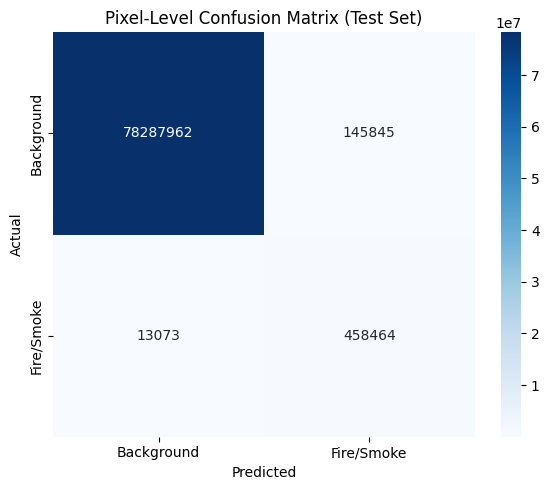

In [26]:
def plot_confusion_matrix(cm, save_path):
    labels = ["Background", "Fire/Smoke"]

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Pixel-Level Confusion Matrix (Test Set)")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

plot_confusion_matrix(
    pixel_metrics['confusion_matrix'],
    "/content/drive/MyDrive/flame_data/checkpoints/confusion_matrix.png"
)

In [27]:
def get_per_image_iou(model, loader, device):
    model.eval()
    results = []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(pixel_values=images)
            logits = outputs.logits

            upsampled_logits = torch.nn.functional.interpolate(
                logits, size=masks.shape[-2:], mode="bilinear", align_corners=False
            )

            preds = torch.argmax(upsampled_logits, dim=1)

            for i in range(images.shape[0]):
                pred_i = preds[i]   # Predicted mask for the current image.
                mask_i = masks[i]   # Ground truth mask for the current image.

                # Create binary masks for the 'fire/smoke' class (class 1).
                pred_fire = (pred_i == 1)
                mask_fire = (mask_i == 1)

                # Calculate intersection and union for the 'fire/smoke' class.
                intersection = (pred_fire & mask_fire).sum().item()
                union = (pred_fire | mask_fire).sum().item()

                # Calculate IoU for the 'fire/smoke' class. Handle cases where union is zero (no fire/smoke in GT or pred).
                iou = intersection / union if union > 0 else 1.0

                results.append({
                    "iou": iou,
                    "image": images[i].cpu(),
                    "mask": mask_i.cpu(),
                    "pred": pred_i.cpu()
                })

    return results

per_image_results = get_per_image_iou(model, test_loader, device)
per_image_results.sort(key=lambda x: x["iou"])

print(f"Worst 5 IoU scores: {[round(r['iou'], 4) for r in per_image_results[:5]]}")
print(f"Best 5 IoU scores: {[round(r['iou'], 4) for r in per_image_results[-5:]]}")

Worst 5 IoU scores: [0.2688, 0.3538, 0.359, 0.3835, 0.4012]
Best 5 IoU scores: [0.8534, 0.8536, 0.8716, 0.9188, 0.9379]


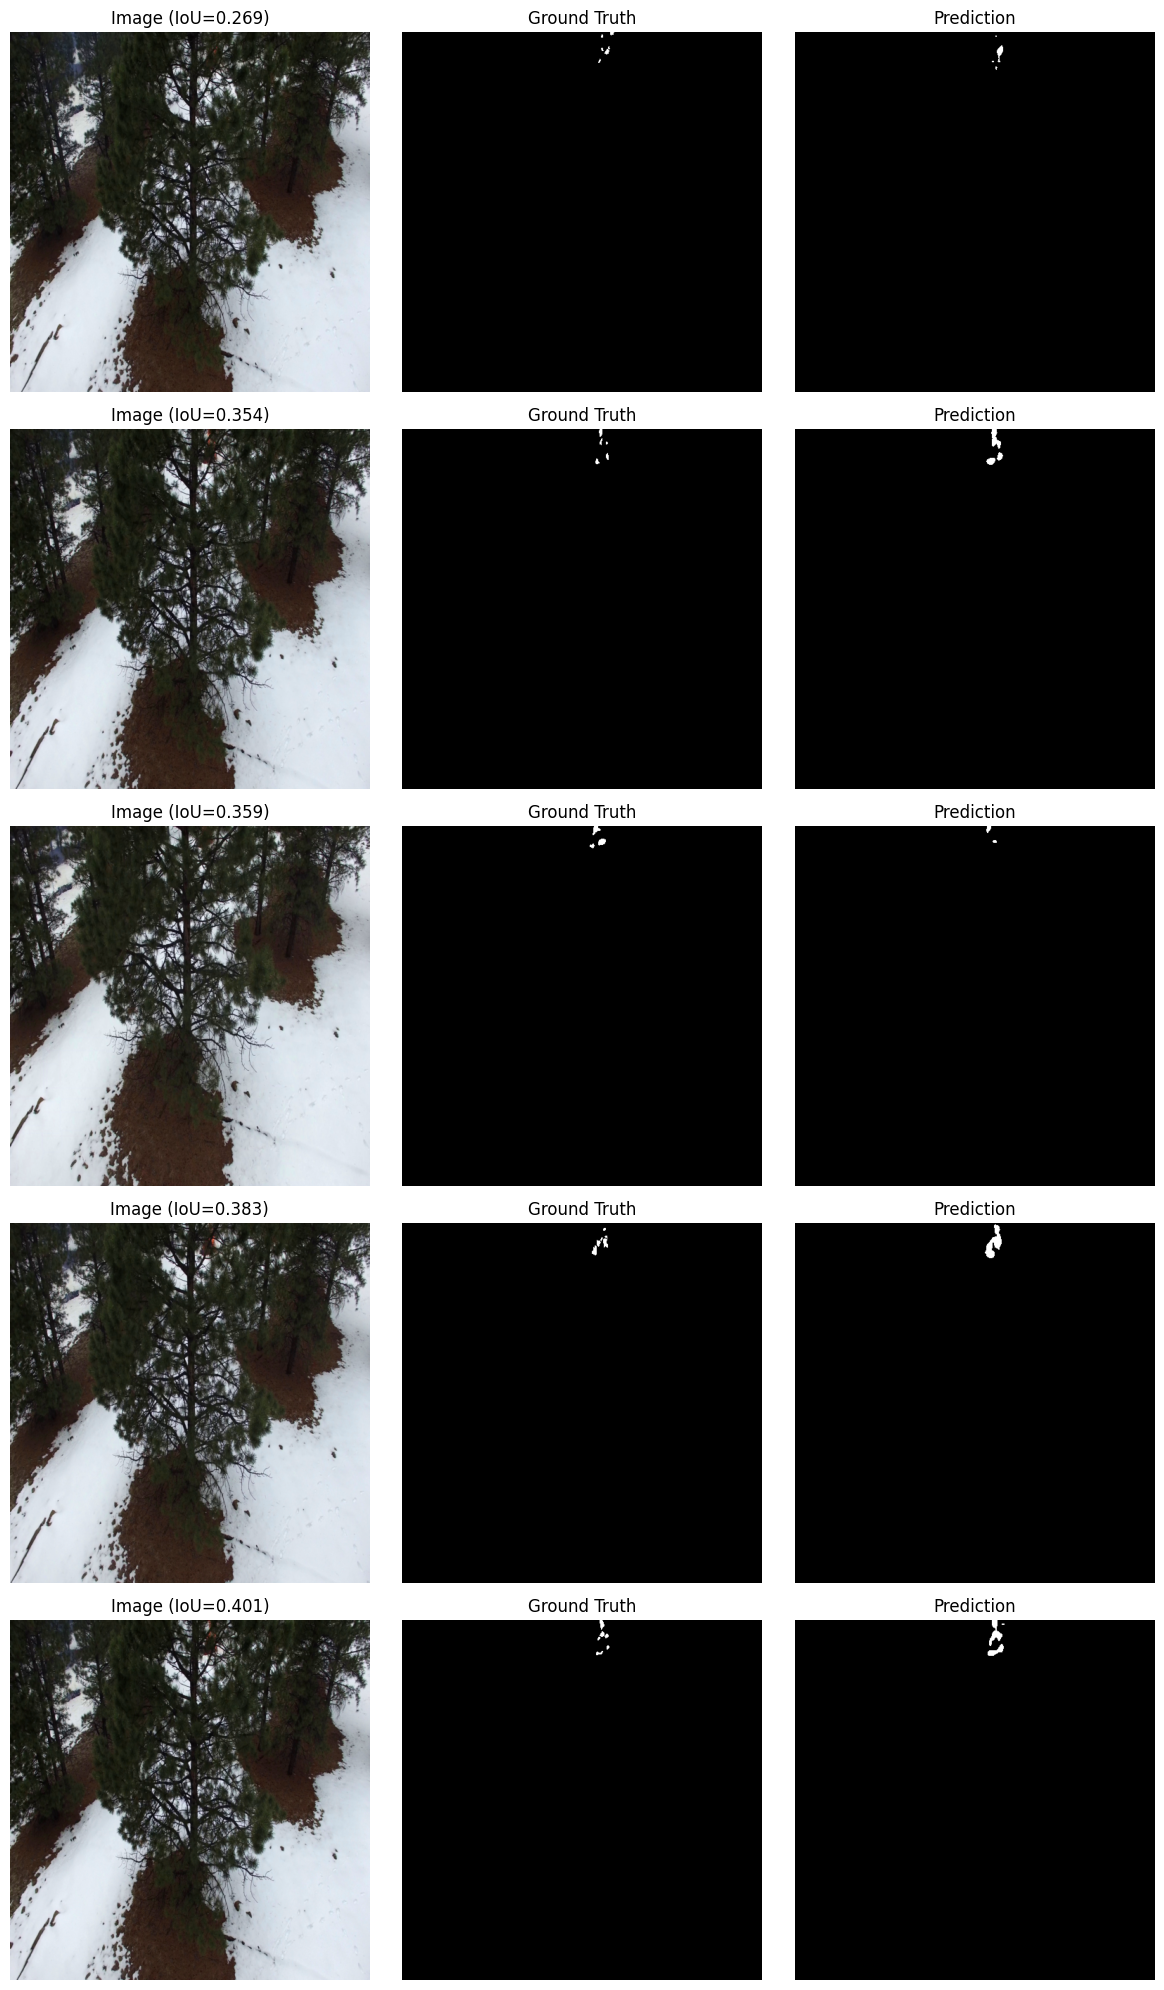

In [28]:
import matplotlib.pyplot as plt

def visualize_failures(results, num_examples=5):
    fig, axes = plt.subplots(num_examples, 3, figsize=(12, 4 * num_examples))

    for idx in range(num_examples):
        item = results[idx]
        # Permute the dimensions of the image tensor from (C, H, W) to (H, W, C) for Matplotlib.
        img = item["image"].permute(1, 2, 0).numpy()
        # Normalize image pixel values to [0, 1] for proper display, especially if original images were normalized.
        img = (img - img.min()) / (img.max() - img.min())

        gt = item["mask"].numpy()
        pred = item["pred"].numpy()

        # Display the original image.
        axes[idx, 0].imshow(img)
        axes[idx, 0].set_title(f"Image (IoU={item['iou']:.3f})")
        axes[idx, 0].axis("off")

        # Display the ground truth mask using a grayscale colormap.
        axes[idx, 1].imshow(gt, cmap="gray")
        axes[idx, 1].set_title("Ground Truth")
        axes[idx, 1].axis("off")

        # Display the predicted mask using a grayscale colormap.
        axes[idx, 2].imshow(pred, cmap="gray")
        axes[idx, 2].set_title("Prediction")
        axes[idx, 2].axis("off")

    # Adjust layout to prevent titles and labels from overlapping.
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/flame_data/checkpoints/failure_cases.png", dpi=150)
    plt.show()

# Call the visualize_failures function to display the 5 worst performing images.
visualize_failures(per_image_results, num_examples=5)

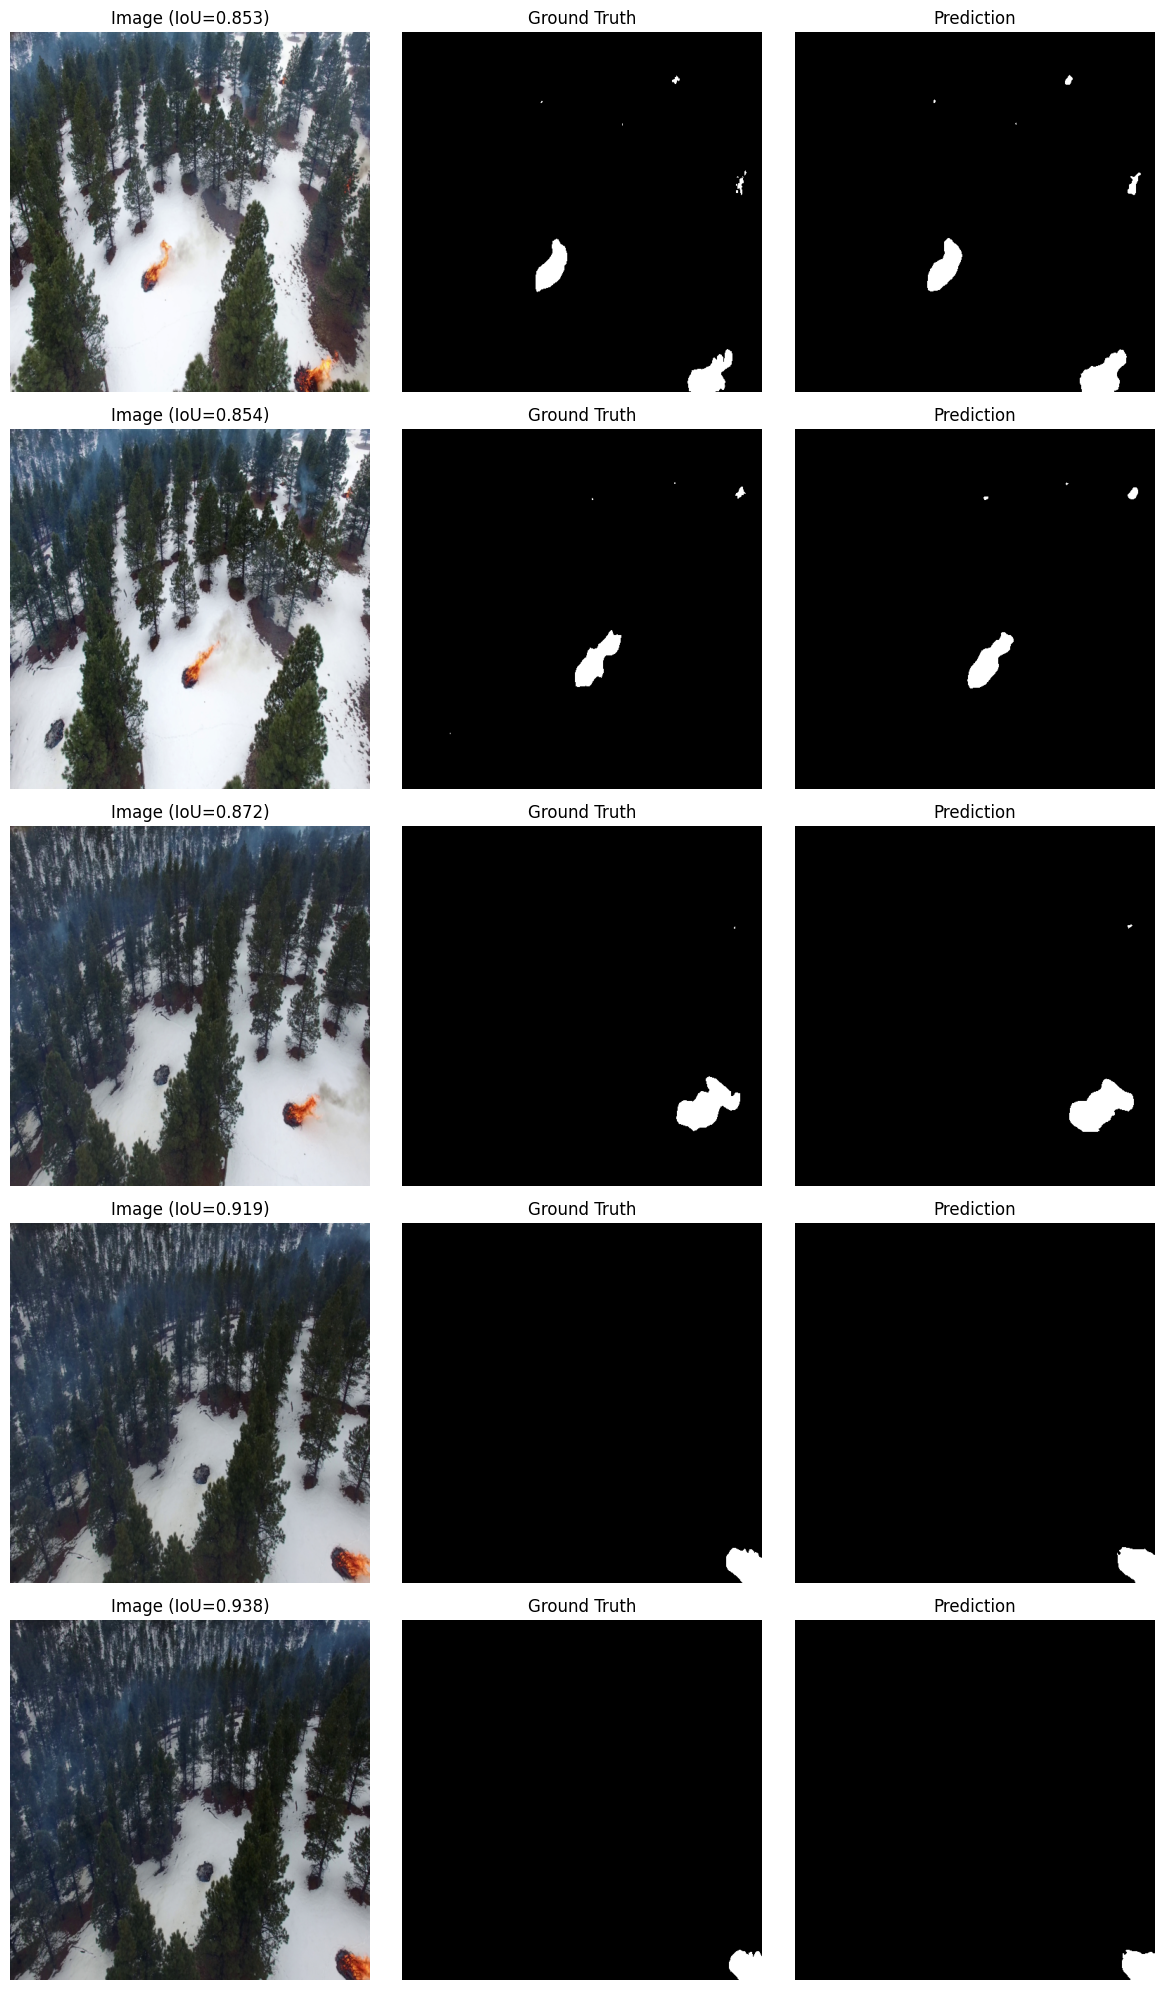

In [29]:
def visualize_best_cases(results, num_examples=5):
    fig, axes = plt.subplots(num_examples, 3, figsize=(12, 4 * num_examples))

    best_results = results[-num_examples:]

    for idx, item in enumerate(best_results):
        img = item["image"].permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())

        gt = item["mask"].numpy()
        pred = item["pred"].numpy()

        # Display the original image.
        axes[idx, 0].imshow(img)
        axes[idx, 0].set_title(f"Image (IoU={item['iou']:.3f})")
        axes[idx, 0].axis("off")

        # Display the ground truth mask using a grayscale colormap.
        axes[idx, 1].imshow(gt, cmap="gray")
        axes[idx, 1].set_title("Ground Truth")
        axes[idx, 1].axis("off")

        # Display the predicted mask using a grayscale colormap.
        axes[idx, 2].imshow(pred, cmap="gray")
        axes[idx, 2].set_title("Prediction")
        axes[idx, 2].axis("off")

    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/flame_data/checkpoints/best_cases.png", dpi=150)
    plt.show()

visualize_best_cases(per_image_results, num_examples=5)